In [1]:
import math
from statistics import mean
import csv
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import tdt
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal
import os
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
###low pass filter pupil
def filter_pupil(pupil,order = 1,cutoff = 1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y

    return butter_lowpass_filter(pupil, cutoff, fs, order)

In [3]:
### get pupil events
###get events from all sessions

def get_pupil_events(id,date):
    id = id
    date = date
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    
    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        aucs.append(np.trapz(dff[onset:offset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "aucs" : aucs,
    "mean_dff" : mean_dffs,


    }
    

    return pd.DataFrame.from_dict(events_dict)


In [4]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [5]:
###get raw pupil#
id = "004116"
date = "20230815"
face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
df = pd.read_csv(path)
pupil = np.array(df["Pupil Size"])
time = np.array(df["Time"])
events = get_pupil_events(id,date)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8989/3932966678.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(range(0,90,10))


[Text(1510.0, 0, '0'),
 Text(1520.0, 0, '10'),
 Text(1530.0, 0, '20'),
 Text(1540.0, 0, '30'),
 Text(1550.0, 0, '40'),
 Text(1560.0, 0, '50'),
 Text(1570.0, 0, '60'),
 Text(1580.0, 0, '70'),
 Text(1590.0, 0, '80')]

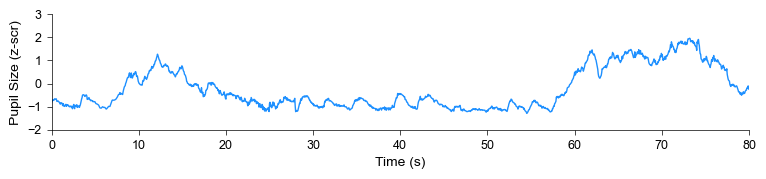

In [6]:
###raw pupil
plt.figure(figsize = (9,1.5))
plt.plot(time,pupil,color = "dodgerblue",linewidth = 1)
plt.xlim(1510,1590)
plt.ylim(-2,3)
plt.xlabel("Time (s)")
plt.ylabel("Pupil Size (z-scr)")
plt.yticks(np.arange(-2,4,1))
plt.gca().set_xticklabels(range(0,90,10))

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8989/1627933503.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(range(0,90,10))


[Text(1510.0, 0, '0'),
 Text(1520.0, 0, '10'),
 Text(1530.0, 0, '20'),
 Text(1540.0, 0, '30'),
 Text(1550.0, 0, '40'),
 Text(1560.0, 0, '50'),
 Text(1570.0, 0, '60'),
 Text(1580.0, 0, '70'),
 Text(1590.0, 0, '80')]

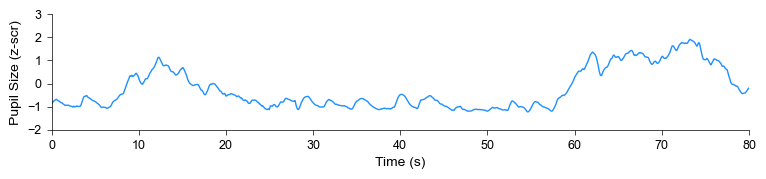

In [7]:
###bandpass filter pupil
plt.figure(figsize = (9,1.5))

filter = filter_pupil(pupil)
plt.plot(time,filter,color = "dodgerblue",linewidth = 1)
plt.xlim(1510,1590)
plt.ylim(-2,3)
plt.xlabel("Time (s)")
plt.ylabel("Pupil Size (z-scr)")
plt.yticks(np.arange(-2,4,1))
plt.gca().set_xticklabels(range(0,90,10))


(-2.0, 2.5)

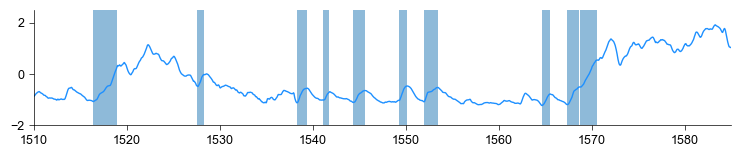

In [8]:
###find regions 
plt.figure(figsize = (9,1.5))

def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


regions = list(groupSequence(filter))
corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median
region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region

for region in region_ix:
    plt.axvspan((region[0])/20,(region[-1])/20,alpha = 0.5)
plt.plot(time,filter,color = "dodgerblue",linewidth = 1)
plt.xlim(1510,1585)
plt.ylim(-2,2.5)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8989/1621360319.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(range(0,90,10))


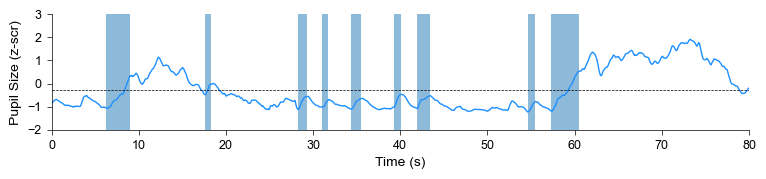

In [9]:
###join regions that are close

new = []
for i,first in enumerate(region_ix):
    if i < len(region_ix)-1:
        second = region_ix[i + 1]
        end = first[-1]
        start = second[0]
        if first[0] - region_ix[i - 1][-1]>20:
            if start-end<= 20:
                #print(first[0]/20,second[0]/20)
                new.append(first + second)
            else:
                new.append(first)
region_ix = new
corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


new = []
for i,first in enumerate(region_ix):
    if i < len(region_ix)-1:
        second = region_ix[i + 1]
        end = first[-1]
        start = second[0]
        if first[0] - region_ix[i - 1][-1]>10:
            if start-end<= 10:
                #print(first[0]/20,second[0]/20)
                new.append(first + second)
            else:
                new.append(first)
region_ix = new
corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
onsets_ix = [region[0] for region in region_ix]

plt.figure(figsize = (9,1.5))
for region in region_ix:
    if ((region[0]/20 > 1510) and (region[0]/20 < 1590)):
        plt.axvspan((region[0])/20,(region[-1])/20,alpha = 0.5)
plt.plot(time,filter,color = "dodgerblue",linewidth = 1)
plt.xlim(1510,1590)
plt.ylim(-2,3)
plt.xlabel("Time (s)")
plt.ylabel("Pupil Size (z-scr)")
plt.yticks(np.arange(-2,4,1))
plt.gca().set_xticklabels(range(0,90,10))
plt.gca().axhline(np.median(filter),linestyle = "dashed", color = "black",linewidth = 0.5)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8989/3393853936.py:47: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(range(0,90,10))


[Text(1510.0, 0, '0'),
 Text(1520.0, 0, '10'),
 Text(1530.0, 0, '20'),
 Text(1540.0, 0, '30'),
 Text(1550.0, 0, '40'),
 Text(1560.0, 0, '50'),
 Text(1570.0, 0, '60'),
 Text(1580.0, 0, '70'),
 Text(1590.0, 0, '80')]

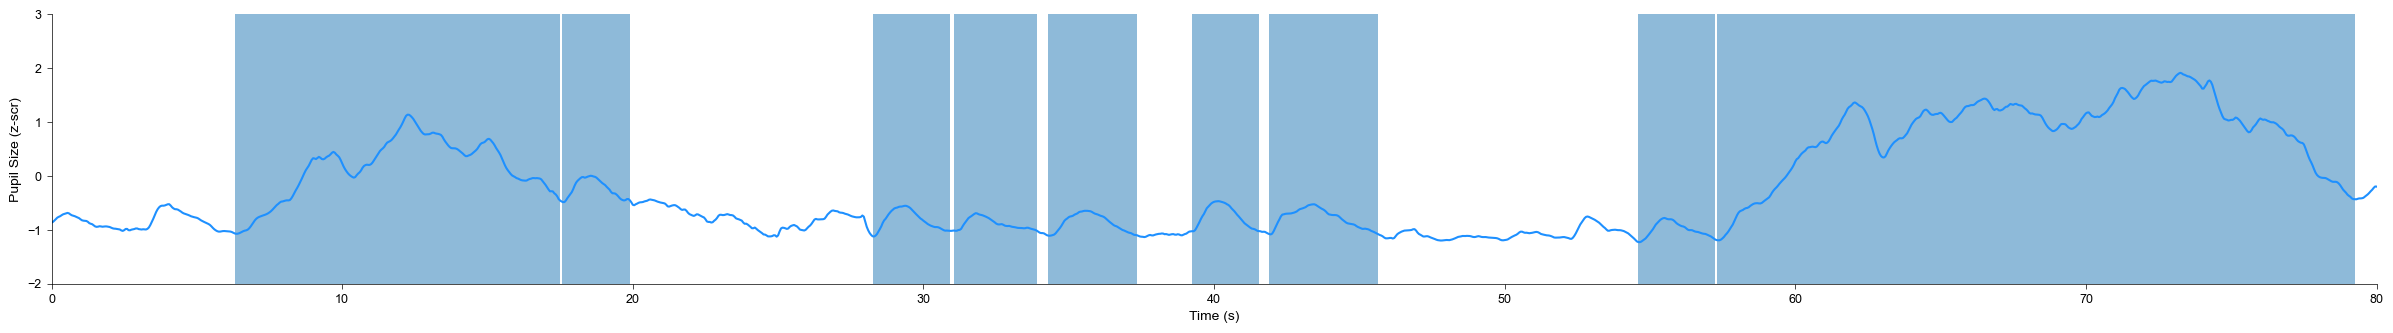

In [10]:
###get offsets and durations for pupil event
offset_ix = []
durations = []
for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
    if i < len(region_ix)-1:
        start = index[-1] ###end of region
        end = region_ix[i+1][0] ### start of next region
        onset_y = region[0]
        offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
    if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
        offset = start + np.argmin(filter[start:end])
    else:
        offset = start + offsets[0][0]


    offset_ix.append(offset)

    durations.append((offset-index[0])/20)

###handle last pupil event
start = region_ix[-1][-1]
end = 36000
onset_y = corrected_regions[-1][0]
offsets = np.where(filter[start:end] <= onset_y)
if len(offsets[0]) == 0:
    offset = end-1
else:
    offset = start + np.argmin(filter[start:end])

offset_ix[-1] = offset

durations[-1] = (offset-region_ix[-1][0])/20

plt.figure(figsize = (30,3.5))

offsets = [off/20 for off in offset_ix]
onsets = [on/20 for on in onsets_ix]
for on,off in zip(onsets,offsets):
    plt.axvspan(on,off,alpha = 0.5)

plt.plot(time,filter,color = "dodgerblue")
plt.xlim(1510,1590)
plt.ylim(-2,3)
plt.xlabel("Time (s)")
plt.ylabel("Pupil Size (z-scr)")
plt.yticks(np.arange(-2,4,1))
plt.gca().set_xticklabels(range(0,90,10))

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8989/1865822112.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(range(0,90,10))


[Text(1510.0, 0, '0'),
 Text(1520.0, 0, '10'),
 Text(1530.0, 0, '20'),
 Text(1540.0, 0, '30'),
 Text(1550.0, 0, '40'),
 Text(1560.0, 0, '50'),
 Text(1570.0, 0, '60'),
 Text(1580.0, 0, '70'),
 Text(1590.0, 0, '80')]

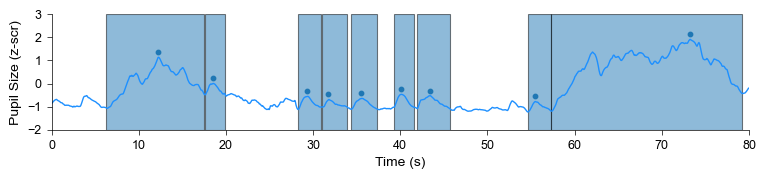

In [11]:
###get event amplitudes
amplitudes = []
amplitudes_ix = []
for on,off in zip(onsets_ix,offset_ix):
    amplitudes.append(max(filter[on:off])-filter[on])
    amplitudes_ix.append(on + np.argmax(filter[on:off]))

amp_vals = [filter[ix] + 0.22 for ix in amplitudes_ix]
amp_times = [ix/20 for ix in amplitudes_ix]

plt.figure(figsize = (9,1.5))

plt.scatter(amp_times,amp_vals, s = 10)

for on,off in zip(onsets,offsets):
    if (on > 1510) and (off < 1590):
        plt.axvspan(on,off,alpha = 0.5,edgecolor = "black",linewidth = 0.8)

plt.plot(time,filter,color = "dodgerblue",linewidth = 1)
plt.xlim(1510,1590)
plt.ylim(-2,3)
plt.xlabel("Time (s)")
plt.ylabel("Pupil Size (z-scr)")
plt.yticks(np.arange(-2,4,1))
plt.gca().set_xticklabels(range(0,90,10))

In [15]:
### Get data for Fig2E
id_date = {
"004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
  
}

labels = ["1","2","3","4"]

df_list = []
for id,dates in id_date.items():
    for date in dates:
        events = get_pupil_events(id,date)
        events["animal_amp_bin"] = pd.qcut(events["amplitudes"], q=4,labels = labels)
        df_list.append(events)
        

acc_event_df = pd.concat(df_list)

# Group by session (ID + Date)
session_counts = (
    acc_event_df.groupby(["ID", "Date"])
      .size()
      .reset_index(name="n_events")
)

# Add event frequency (events / 1800 seconds)
session_counts["event_freq"] = session_counts["n_events"] / 1800


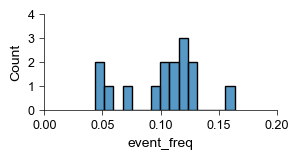

In [16]:
### Plot FigS2E
plt.figure(figsize = (3,1.25))
ax = sns.histplot(data = session_counts, x = "event_freq",bins =15)
format_ax(ax,(0,0.2),(0,4),0.05,1)